In [23]:
import sklearn
import random
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [24]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  

In [25]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [26]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

sklearn   : 1.5.1
tensorflow: 2.19.0
pandas    : 2.3.1
matplotlib: 3.9.2
numpy     : 1.26.4



In [27]:
df = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/Projetos de Machine Learning/dataset.csv')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ano                          55 non-null     int64  
 1   otif                         55 non-null     float64
 2   lead_time                    55 non-null     float64
 3   custo_transporte             55 non-null     float64
 4   indice_rotatividade_estoque  55 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 2.3 KB


In [29]:
df.shape

(55, 5)

In [30]:
df.head()

,ano,otif,lead_time,custo_transporte,indice_rotatividade_estoque
0,1970,11.43,5.63,1980.10,0.15
1,1971,14.59,7.34,1930.63,0.39
2,1972,12.45,6.58,1057.70,2.46
3,1973,11.35,14.45,2881.87,0.73
4,1974,9.05,8.05,1617.81,1.48


In [31]:
df.tail()

,ano,otif,lead_time,custo_transporte,indice_rotatividade_estoque
50,2020,11.83,19.40,2518.30,1.69
51,2021,9.33,7.98,1922.75,1.70
52,2022,19.78,13.22,1517.96,1.72
53,2023,18.78,14.22,1617.96,1.73
54,2024,17.48,19.32,1717.96,1.79


In [32]:
indice_rotatividade_estoque = df['indice_rotatividade_estoque'].values.reshape(-1, 1)

In [33]:
indice_rotatividade_estoque

array([[ 0.15],
       [ 0.39],
       [ 2.46],
       [ 0.73],
       [ 1.48],
       [ 1.12],
       [ 0.41],
       [ 0.48],
       [ 1.15],
       [ 0.31],
       [ 0.58],
       [ 0.23],
       [ 0.57],
       [ 2.79],
       [ 0.43],
       [ 2.9 ],
       [-0.2 ],
       [ 1.8 ],
       [ 0.  ],
       [ 0.3 ],
       [ 1.72],
       [ 1.1 ],
       [ 2.26],
       [ 0.86],
       [ 2.6 ],
       [-0.17],
       [-0.49],
       [ 2.6 ],
       [ 0.38],
       [-1.  ],
       [ 2.19],
       [ 1.84],
       [ 0.33],
       [-0.38],
       [-2.4 ],
       [ 2.16],
       [ 2.77],
       [-2.45],
       [ 0.82],
       [ 0.64],
       [ 1.3 ],
       [ 0.34],
       [ 0.93],
       [ 0.53],
       [ 0.85],
       [ 0.5 ],
       [ 0.66],
       [ 0.98],
       [ 0.97],
       [ 1.63],
       [ 1.69],
       [ 1.7 ],
       [ 1.72],
       [ 1.73],
       [ 1.79]])

In [34]:
def prepara_dados(data, look_back=1):
    X, Y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)])
        Y.append(data[i + look_back])
    return np.array(X), np.array(Y)

In [35]:
indice = int(len(indice_rotatividade_estoque) * 0.8)
dados_treino, dados_teste = indice_rotatividade_estoque[0:indice, :], indice_rotatividade_estoque[indice:len(indice_rotatividade_estoque), :]

In [36]:
dados_treino

array([[ 0.15],
       [ 0.39],
       [ 2.46],
       [ 0.73],
       [ 1.48],
       [ 1.12],
       [ 0.41],
       [ 0.48],
       [ 1.15],
       [ 0.31],
       [ 0.58],
       [ 0.23],
       [ 0.57],
       [ 2.79],
       [ 0.43],
       [ 2.9 ],
       [-0.2 ],
       [ 1.8 ],
       [ 0.  ],
       [ 0.3 ],
       [ 1.72],
       [ 1.1 ],
       [ 2.26],
       [ 0.86],
       [ 2.6 ],
       [-0.17],
       [-0.49],
       [ 2.6 ],
       [ 0.38],
       [-1.  ],
       [ 2.19],
       [ 1.84],
       [ 0.33],
       [-0.38],
       [-2.4 ],
       [ 2.16],
       [ 2.77],
       [-2.45],
       [ 0.82],
       [ 0.64],
       [ 1.3 ],
       [ 0.34],
       [ 0.93],
       [ 0.53]])

In [37]:
dados_teste

array([[0.85],
       [0.5 ],
       [0.66],
       [0.98],
       [0.97],
       [1.63],
       [1.69],
       [1.7 ],
       [1.72],
       [1.73],
       [1.79]])

In [38]:
scaler = MinMaxScaler(feature_range=(0, 1))

In [39]:
dados_treino_norm = scaler.fit_transform(dados_treino)
dados_teste_norm = scaler.transform(dados_teste)

In [40]:
look_back = 1
X_treino, y_treino = prepara_dados(dados_treino_norm, look_back)
X_teste, y_teste = prepara_dados(dados_teste_norm, look_back)

In [41]:
'''X_treino = np.reshape(X_treino, (X_treino.shape[0], look_back, 1))
X_teste = np.reshape(X_teste, (X_teste.shape[0], look_back, 1))'''

y_treino_2d = y_treino.reshape(-1, 1)
y_teste_2d = y_teste.reshape(-1, 1)

In [42]:
modelo = tf.keras.models.Sequential([tf.keras.layers.LSTM(50, input_shape = (look_back, 1)),
                                     tf.keras.layers.Dense(1)])

In [43]:
modelo.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [44]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
modelo.fit(X_treino, y_treino, epochs = 50, batch_size = 1, verbose = 1)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3253
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1322
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0533
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0519
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0539
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0527
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0514
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0501
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0489
Epoch 10/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0477
Epoch 11/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0465
Epoch 12/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0455
Epoch 13/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0444
Epoch 14/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0434
Epoch 15/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0425
Epoch 16/50
43/43 ━

In [46]:
previsao_treino = modelo.predict(X_treino)
previsao_teste = modelo.predict(X_teste)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [47]:
previsao_treino = scaler.inverse_transform(previsao_treino)
y_treino_rescaled = scaler.inverse_transform(y_treino_2d)
previsao_teste = scaler.inverse_transform(previsao_teste)
y_teste_rescaled = scaler.inverse_transform(y_teste_2d)

In [48]:
original_train_data_index = df['ano'][look_back:look_back + len(y_treino_rescaled[0])]

In [51]:
original_test_data_index = df['ano'][len(y_treino_rescaled[0]) + 2 * look_back:len(y_treino_rescaled[0]) + 2 * look_back + len(y_teste_rescaled[0])]

In [52]:
predicted_train_data_index = df['ano'][look_back + len(previsao_treino)]

In [54]:
predicted_test_data_index = df['ano'][len(y_treino_rescaled[0]) + 2 * look_back : len(y_treino_rescaled[0]) + 2 * look_back + len(previsao_teste)]

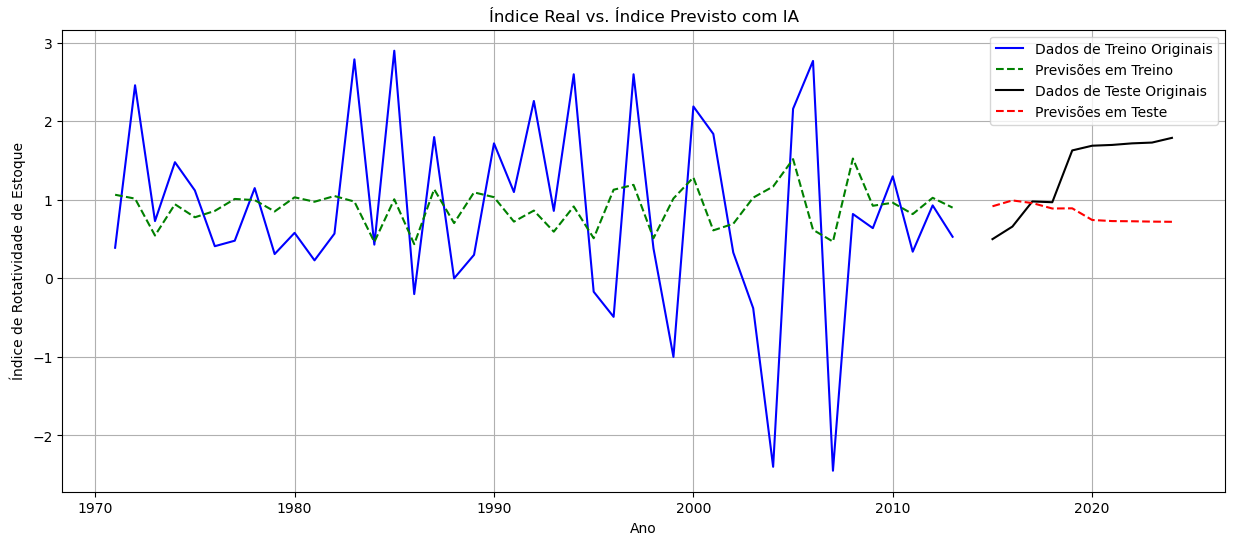

In [ ]:
plt.figure(figsize = (15, 6))

plt.plot(df['ano'][1:1 + len(y_treino_rescaled)], 
         y_treino_rescaled.flatten(), 
         label = "Dados de Treino Originais",
         color = 'blue',
         linestyle = '-')

plt.plot(df['ano'][1:1 + len(previsao_treino)], 
         previsao_treino.flatten(), 
         label = 'Previsões em Treino',
         color = "green", linestyle='--')

plt.plot(df['ano'][len(y_treino_rescaled) + 2 * look_back : len(y_treino_rescaled) + 2 * look_back + len(y_teste_rescaled)], 
         y_teste_rescaled.flatten(), 
         label = "Dados de Teste Originais",
         color = "black",
         linestyle = '-')

plt.plot(df['ano'][len(y_treino_rescaled) + 2 * look_back : len(y_treino_rescaled) + 2 * look_back + len(previsao_teste)], 
         previsao_teste.flatten(), 
         label = "Previsões em Teste",
         color = "red",
         linestyle = '--')

plt.title("Índice Real vs. Índice Previsto com IA")
plt.xlabel("Ano")
plt.ylabel("Índice de Rotatividade de Estoque")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
last_data = dados_teste_norm[-look_back:]
last_data = np.reshape(last_data, (1, look_back, 1))

In [59]:
lista_previsoes = []

In [63]:
for _ in range(2):

    prediction = modelo.predict(last_data)
    lista_previsoes.append(prediction[0,0])

    last_data = np.roll(last_data, shift =-1)
    last_data[0, look_back - 1, 0] = prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [64]:
lista_previsoes_rescaled = scaler.inverse_transform(np.array(lista_previsoes).reshape(-1, 1))

In [65]:
print(f"Previsão do Índice de Rotatividade de Estoque Para 2025: {lista_previsoes_rescaled[0, 0]:.2f}")
print(f"Previsão do Ìndice de Rotatividade de Estoque Para 2026: {lista_previsoes_rescaled[1, 0]:.2f}")

Previsão do Índice de Rotatividade de Estoque Para 2025: 0.71
Previsão do Ìndice de Rotatividade de Estoque Para 2026: 0.95


In [66]:
%watermark -a "Matheus dos Anjos"

Author: Matheus dos Anjos

